# RandomForest — Strategy Discovery

**Prerequisites:**
- Run `data/01_build_features.ipynb` to generate `data/latest_features.jsonl`
- Run `rf/03_export.ipynb` to export the model to `models/`

**Goal:** Find the best scaling-in strategy for RandomForest on forward-test candles.
Loads pre-trained model from `models/` (no re-training).
Saves best strategy to `data/optimal_strategy_rf.json`.


In [1]:
import sys

sys.path.insert(0, str(__import__("pathlib").Path.cwd().parent))

import json
import random
import sqlite3
from datetime import UTC, datetime
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from technicals import CandleRecord, IndicatorSnapshot, compute_all
from tqdm import tqdm

random.seed(42)
np.random.seed(42)

FEATURES_PATH = Path("../../data/latest_features.jsonl")
DB_PATH = Path("../../data/collection.db")
MODELS_DIR = Path("../../models")
MAX_BID = 0.85
WARM_UP = 21

## 1. Load pre-trained model

In [2]:
model = joblib.load(MODELS_DIR / "rf_v1.joblib")
scaler = joblib.load(MODELS_DIR / "rf_scaler_v1.joblib")
feat_cols = joblib.load(MODELS_DIR / "rf_feature_cols_v1.joblib")

rf_params = sum(e.tree_.node_count for e in model.estimators_) * 2
print(f"RF loaded: {rf_params:,} params, {len(feat_cols)} features")

RF loaded: 715,588 params, 15 features


## 2. Find training data cutoff + load new candles

In [3]:
rows = []
with open(FEATURES_PATH) as f:
    for line in f:
        rows.append(json.loads(line))
df_train = pd.DataFrame(rows)
max_train_ts = df_train["timestamp"].max()
print(f"Training cutoff: {df_train['candle_id'].nunique()} candles")
del df_train

conn = sqlite3.connect(str(DB_PATH))
candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time > {max_train_ts} ORDER BY start_time",
    conn,
)
snaps_df = (
    pd.read_sql(
        "SELECT * FROM snapshots WHERE candle_id IN ({}) ORDER BY candle_id, timestamp".format(
            ",".join(f"'{cid}'" for cid in candles_df["candle_id"])
        ),
        conn,
    )
    if len(candles_df) > 0
    else pd.DataFrame()
)
prior_candles_df = pd.read_sql(
    f"SELECT * FROM candles WHERE start_time <= {max_train_ts} ORDER BY start_time DESC LIMIT {WARM_UP}",
    conn,
)
conn.close()

prior_candles_df = prior_candles_df.sort_values("start_time")
prior_candles = []
for _, cr in prior_candles_df.iterrows():
    prior_candles.append(
        CandleRecord(
            candle_id=cr["candle_id"],
            start_time=cr["start_time"],
            end_time=cr["end_time"],
            open=cr["open"],
            high=cr["high"],
            low=cr["low"],
            close=cr["close"],
            volume=cr["volume"],
            outcome=cr["outcome"],
            final_ret=cr["final_ret"],
        )
    )

all_feat_cols = sorted(set(feat_cols))
all_rows = []
for _, cr in tqdm(candles_df.iterrows(), total=len(candles_df), desc="Computing features"):
    cid = cr["candle_id"]
    candle = CandleRecord(
        candle_id=cid,
        start_time=cr["start_time"],
        end_time=cr["end_time"],
        open=cr["open"],
        high=cr["high"],
        low=cr["low"],
        close=cr["close"],
        volume=cr["volume"],
        outcome=cr["outcome"],
        final_ret=cr["final_ret"],
    )
    snap_rows = snaps_df[snaps_df["candle_id"] == cid]
    if len(snap_rows) < 5:
        prior_candles.append(candle)
        continue
    snapshots = []
    for _, s in snap_rows.iterrows():
        ob = json.loads(s["orderbook_json"])
        snapshots.append(
            IndicatorSnapshot(
                candle_id=cid,
                timestamp=s["timestamp"],
                elapsed_pct=s["elapsed_pct"],
                btc_price=s["btc_price"],
                btc_bid=s["btc_bid"],
                btc_ask=s["btc_ask"],
                up_bids=[ob["up_bids"][0]] if ob.get("up_bids") else [],
                up_asks=[ob["up_asks"][0]] if ob.get("up_asks") else [],
                down_bids=[ob["down_bids"][0]] if ob.get("down_bids") else [],
                down_asks=[ob["down_asks"][0]] if ob.get("down_asks") else [],
                market_volume=s["market_volume"],
            )
        )
    for si in range(len(snapshots)):
        indicators = compute_all(prior_candles, candle.open, snapshots[: si + 1])
        snap = snapshots[si]
        row = {
            "candle_id": cid,
            "timestamp": snap.timestamp,
            "elapsed_pct": snap.elapsed_pct,
            "btc_price": snap.btc_price,
            "up_best_ask": snap.up_asks[0][0] if snap.up_asks else None,
            "down_best_ask": snap.down_asks[0][0] if snap.down_asks else None,
            **indicators,
            "outcome": candle.outcome,
        }
        all_rows.append(row)
    prior_candles.append(candle)

df_eval = pd.DataFrame(all_rows)
df_eval["target"] = (df_eval["outcome"] == "UP").astype(int)
for col in all_feat_cols:
    if col not in df_eval.columns:
        df_eval[col] = 0.0
df_eval[all_feat_cols] = df_eval[all_feat_cols].fillna(0.0)

print(f"\nForward-test candles: {df_eval['candle_id'].nunique()}")
print(f"Rows: {len(df_eval):,}")

Training cutoff: 1376 candles


Computing features: 100%|██████████| 185/185 [00:01<00:00, 134.79it/s]


Forward-test candles: 185
Rows: 8,742


## 3. Build per-snapshot predictions

In [4]:
all_cd = []
for cid in df_eval["candle_id"].unique():
    snap_rows = df_eval[df_eval["candle_id"] == cid].sort_values("timestamp")
    if len(snap_rows) < 5:
        continue
    truth = int(snap_rows["target"].iloc[0])
    X = scaler.transform(snap_rows[feat_cols].values)
    probs = model.predict_proba(X)[:, 1]

    up_asks = snap_rows["up_best_ask"].values
    down_asks = snap_rows["down_best_ask"].values
    elapsed = snap_rows["elapsed_pct"].values
    sd = [
        {
            "tick": i,
            "elapsed_pct": elapsed[i],
            "pred": int(probs[i] >= 0.5),
            "prob": float(probs[i]),
            "up_ask": up_asks[i],
            "down_ask": down_asks[i],
        }
        for i in range(len(snap_rows))
    ]
    all_cd.append({"candle_id": cid, "truth": truth, "snapshots": sd})

print(f"Built predictions for {len(all_cd)} candles")

Built predictions for 185 candles


## 4. Scaling-in strategy engine

In [5]:
def run_scaling(name, entry_points, bet_per_entry=10.0, min_confidence=0.0):
    bal = 1000.0
    history = [bal]
    total_bets, total_wins, candles_entered = 0, 0, 0

    for cd in all_cd:
        sd = cd["snapshots"]
        truth = cd["truth"]
        entries = []
        first_direction = None

        for min_e, n_c in entry_points:
            for i in range(max(n_c - 1, 0), len(sd)):
                if sd[i]["elapsed_pct"] < min_e:
                    continue
                if any(i <= prev_tick for prev_tick, _, _ in entries):
                    continue
                if n_c > 1 and not all(sd[i - j]["pred"] == sd[i]["pred"] for j in range(n_c)):
                    continue
                confidence = max(sd[i]["prob"], 1.0 - sd[i]["prob"])
                if confidence < min_confidence:
                    continue
                direction = sd[i]["pred"]
                if first_direction is None:
                    first_direction = direction
                elif direction != first_direction:
                    break
                ask = sd[i]["up_ask"] if direction == 1 else sd[i]["down_ask"]
                if ask is None or not np.isfinite(ask) or ask <= 0 or ask >= MAX_BID:
                    continue
                entries.append((i, direction, ask))
                break

        if not entries:
            continue
        candles_entered += 1
        for _, direction, ask in entries:
            if bal < bet_per_entry:
                break
            total_bets += 1
            if direction == truth:
                bal += (bet_per_entry / ask) * (1.0 - ask)
                total_wins += 1
            else:
                bal -= bet_per_entry
        history.append(bal)

    wr = total_wins / total_bets if total_bets > 0 else 0
    max_dd = (
        max((p - h) / p for p, h in zip([max(history[: i + 1]) for i in range(len(history))], history, strict=False))
        if len(history) > 1
        else 0
    )
    return {
        "name": name,
        "balance": bal,
        "history": history,
        "total_bets": total_bets,
        "candles_entered": candles_entered,
        "wins": total_wins,
        "win_rate": wr,
        "return_pct": (bal - 1000) / 1000 * 100,
        "max_dd": max_dd,
    }

## 5. Test strategies

In [6]:
strategies = [
    # Single entry
    ("1x e5%", [(0.05, 3)], 0.0),
    ("1x e5% conf>0.6", [(0.05, 3)], 0.6),
    ("1x e5% conf>0.7", [(0.05, 3)], 0.7),
    # Scaling-in: 2 entries
    ("2x e5%+e50%", [(0.05, 3), (0.50, 3)], 0.0),
    ("2x e5%+e50% conf>0.6", [(0.05, 3), (0.50, 3)], 0.6),
    ("2x e5%+e50% conf>0.7", [(0.05, 3), (0.50, 3)], 0.7),
    # Delayed entry
    ("1x e30%", [(0.30, 3)], 0.0),
    ("2x e30%+e60%", [(0.30, 3), (0.60, 3)], 0.0),
    ("2x e30%+e60% conf>0.6", [(0.30, 3), (0.60, 3)], 0.6),
    # Wide scaling
    ("2x e5%+e70%", [(0.05, 3), (0.70, 3)], 0.0),
    ("2x e5%+e70% conf>0.6", [(0.05, 3), (0.70, 3)], 0.6),
]

results = []
print(f"{'Strategy':<30} {'Bets':>5} {'WR':>6} {'Balance':>10} {'Return':>8} {'MaxDD':>7}")
print("-" * 72)

for name, eps, conf in strategies:
    r = run_scaling(name, eps, min_confidence=conf)
    results.append(r)
    print(
        f"{r['name']:<30} {r['total_bets']:>5} "
        f"{r['win_rate'] * 100:>5.1f}% ${r['balance']:>9.2f} {r['return_pct']:>+7.1f}% {r['max_dd'] * 100:>6.1f}%"
    )

Strategy                        Bets     WR    Balance   Return   MaxDD
------------------------------------------------------------------------
1x e5%                           185  58.9% $  1001.78    +0.2%    9.1%
1x e5% conf>0.6                  185  65.9% $  1087.67    +8.8%    8.0%
1x e5% conf>0.7                  181  69.1% $   946.19    -5.4%   14.4%
2x e5%+e50%                      277  63.9% $  1047.45    +4.7%   14.4%
2x e5%+e50% conf>0.6             284  70.4% $  1182.64   +18.3%    9.1%
2x e5%+e50% conf>0.7             285  71.9% $   974.03    -2.6%   17.9%
1x e30%                          174  66.7% $  1017.17    +1.7%    9.5%
2x e30%+e60%                     264  69.3% $  1060.91    +6.1%   13.2%
2x e30%+e60% conf>0.6            271  72.7% $  1082.10    +8.2%   12.5%
2x e5%+e70%                      248  62.9% $  1057.75    +5.8%   12.8%
2x e5%+e70% conf>0.6             248  69.0% $  1138.39   +13.8%    9.2%


## 6. Equity curves

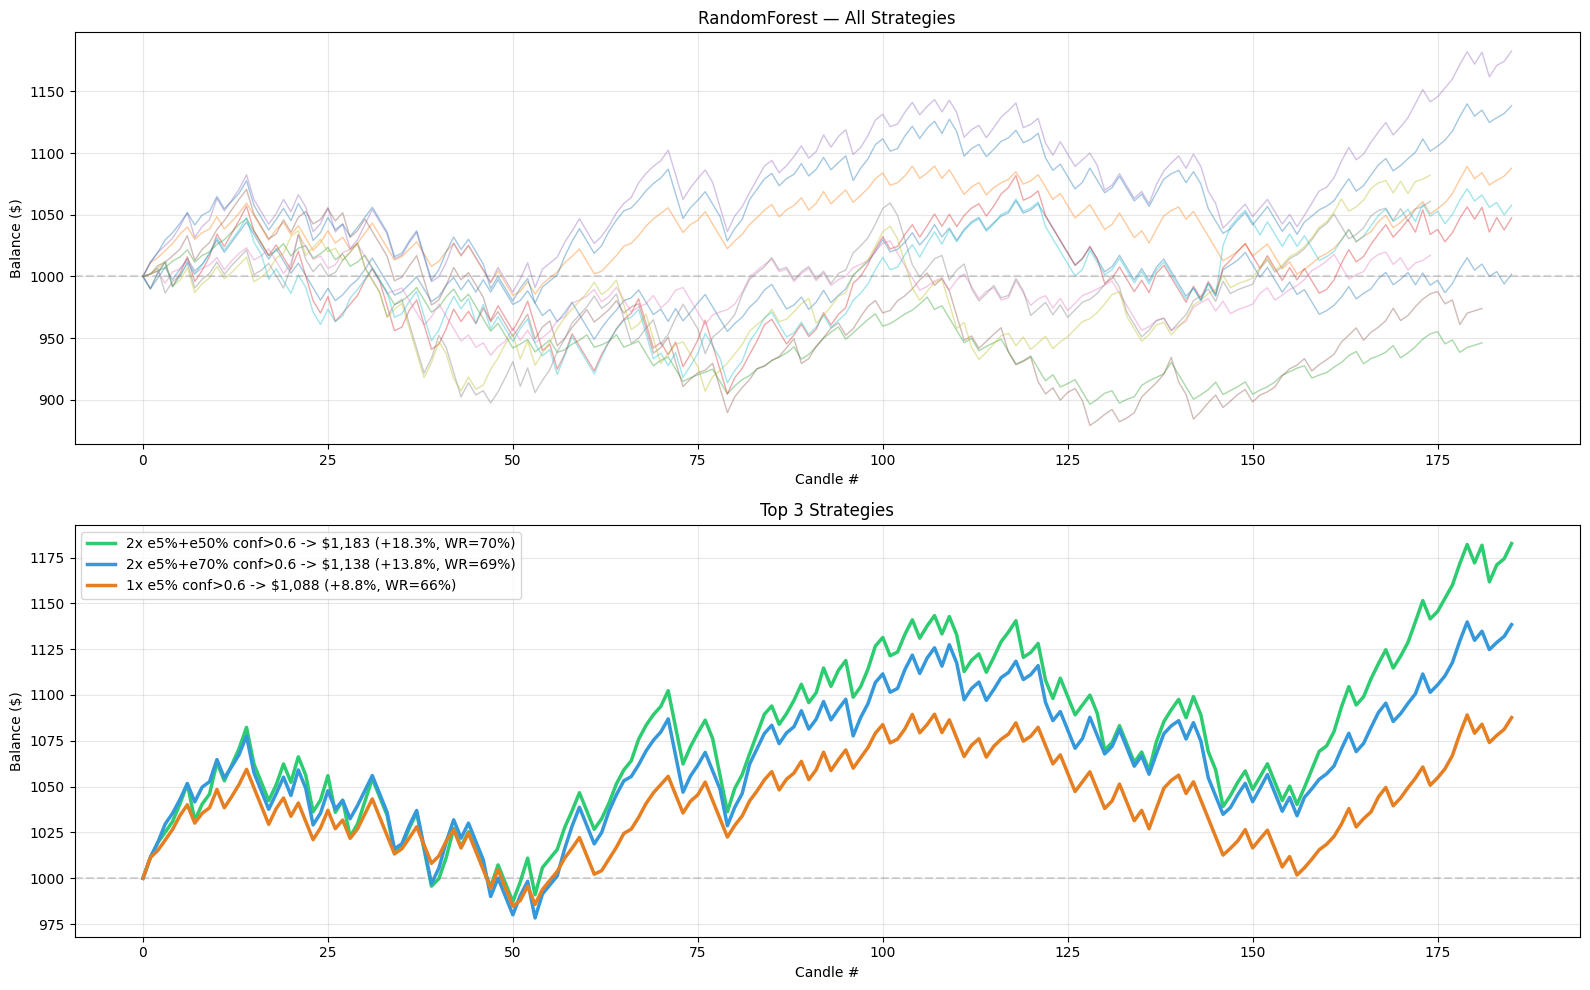

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

for r in results:
    axes[0].plot(r["history"], alpha=0.4, linewidth=1)
axes[0].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[0].set_xlabel("Candle #")
axes[0].set_ylabel("Balance ($)")
axes[0].set_title("RandomForest — All Strategies")
axes[0].grid(alpha=0.3)

# Top 3 by balance
top3 = sorted(results, key=lambda r: -r["balance"])[:3]
colors = ["#2ecc71", "#3498db", "#e67e22"]
for r, c in zip(top3, colors, strict=False):
    axes[1].plot(
        r["history"],
        color=c,
        linewidth=2.5,
        label=f"{r['name']} -> ${r['balance']:,.0f} ({r['return_pct']:+.1f}%, WR={r['win_rate'] * 100:.0f}%)",
    )
axes[1].axhline(1000, color="gray", linestyle="--", alpha=0.3)
axes[1].set_xlabel("Candle #")
axes[1].set_ylabel("Balance ($)")
axes[1].set_title("Top 3 Strategies")
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Save best strategy

In [8]:
best = max(results, key=lambda r: r["balance"])

# Find the entry_points and confidence for the best strategy
best_idx = results.index(best)
best_name, best_eps, best_conf = strategies[best_idx]

config = {
    "model": "rf",
    "strategy": best["name"],
    "entry_points": best_eps,
    "min_confidence": best_conf,
    "win_rate": round(best["win_rate"], 4),
    "return_pct": round(best["return_pct"], 2),
    "max_drawdown": round(best["max_dd"], 4),
    "test_candles": len(all_cd),
    "total_bets": best["total_bets"],
    "created_at": datetime.now(UTC).isoformat(),
}

out_path = Path("../../data/optimal_strategy_rf.json")
with open(out_path, "w") as f:
    json.dump(config, f, indent=2)

print(f"Best strategy: {best['name']}")
print(f"  Win rate: {best['win_rate'] * 100:.1f}%")
print(f"  Return: {best['return_pct']:+.1f}%")
print(f"  Max drawdown: {best['max_dd'] * 100:.1f}%")
print(f"  Balance: ${best['balance']:,.2f}")
print(f"\nSaved to {out_path}")

Best strategy: 2x e5%+e50% conf>0.6
  Win rate: 70.4%
  Return: +18.3%
  Max drawdown: 9.1%
  Balance: $1,182.64

Saved to ../../data/optimal_strategy_rf.json


## 8. Conclusion

Best RandomForest strategy saved to `data/optimal_strategy_rf.json`.
Re-run after collecting more data or re-exporting the model.
